<p style="text-align:right">Титов Павел, МОиАИС 21-3</p>
<h1 style="text-align:center">Лабораторная работа №6</h1>
<h2 style="text-align:center">Тема: построение аппроксимирующего многочлена методом наименьших квадратов</h2>

# Постановка задачи

Приближение (аппроксимация) функции - $f(x) \approx Q(x)$

Отклонение $f(x)$ от $Q(x)$ (в некотором смысле) должно быть наименьшим в заданной области

### Метод наименьших квадратов
В случае МНК $Q(x)$ подбирается так, что сумма квадратов отклонений $Q(x_i)$ от заданных приближенных значений $y_i$ была минимальной

$\Phi(a_0, a_1, \dots, a_m) = \sum\limits_{i=0}^{n} (f(x_i) - Q(x_i, a_0, a_1, \dots, a_m))^2$

Таким образом, мы решаем задачу оптимизации $\Phi(a_0, a_1, \dots, a_m) \rightarrow \Phi_{\min}$

Оптимальный набор параметров     $a_0^*, a_1^*, \dots, a_m^*$
может быть найден из необходимых условий гладкого экстремума, т.е. в результате приравнивания к нулю частных производных функции $\Phi(a_0, a_1, \dots, a_m)$,  взятых по каждому из ее аргументов.

$\frac{\delta\Phi}{\delta a_0} = 0, \frac{\delta\Phi}{\delta a_1} = 0, \dots, \frac{\delta\Phi}{\delta a_m} = 0$

Что сводится к системе уравнений
$\sum\limits_{i=1}^{n}[(a_0 + a_1x_i + \dots + a_nx_i^n) * x_i^k] = 0, k = 0, ..., n$

Решаем СЛУ стандартными методами, находим искомые параметры

#### Порядок выполнения работы
Многократно дифференцируемая функция $y=f(x)$ задана таблицей значений

| **$x$** | $x_0$ | $x_1$ | $\dots$ | $x_n$ |
|---------|-------|-------|---------|-------|
| **$y$** | $y_0$ | $y_1$ | $\dots$ | $y_n$ |

Выбрать отрезок $[a,b]$, разбить его с шагом $h=b-an$, ($n$ - число интервалов разбиения), ввести сетку $x_i=x_0+ih, i=0, 1,\dots,n$ и составить таблицу $\{x_i,f(x_i)\}$

Построить по заданной таблице значений:

Методом наименьших квадратов построить аппроксимирующий многочлен степени $m$:
1. $m = 1$ - линейной функцией;
2. $m = 2$ - квадратичной функцией;
3. $m = 3, 4, \dots$ (тест $n = m$, получаем интерполяционный многочлен, например, n=4)

Результаты представить в виде:

|$\tilde x_i = x_0 + i\frac{h}{2}$|$f(\tilde x_i)$|$Qm(\tilde x_i)$|$\Delta = |f(\tilde x_i) - Qm(\tilde x_i)|$|
|---------------------------------|---------------|----------------|-------------------------------------------|
|                                 |               |                |                                           |

Вычислить и сравнить величины среднеквадратичных отклонений

In [17]:
import numpy as np
# from ipywidgets import interact, Dropdown, FloatRangeSlider, BoundedIntText
from matplotlib import pyplot as plt

Метод Гаусса для решения СЛАУ

In [18]:
def gauss(A, b):
    matrix = np.hstack((A, b.reshape(-1, 1)))

    m, n = matrix.shape
    
    for i in range(m):
        for j in range(i + 1, m):
            matrix[j] -= matrix[i] * (matrix[j, i] / matrix[i, i])

    for i in range(m - 1, -1, -1):
        matrix[i] /= matrix[i, i]
        for j in range(i - 1, -1, -1):
            matrix[j] -= matrix[i] * matrix[j, i]

    return matrix[:, m]

Среднеквадратичное отклонение

In [19]:
def mse(y, y_hat):
    return np.mean((y - y_hat)**2)

Метод наименьших квадратов

In [20]:
def lsm(x, y, m):
    n = len(x)
    pows = x.reshape(n, 1) ** np.arange(m + 1)

    A = pows.T @ pows
    b = pows.T @ y
    
    return gauss(A, b)

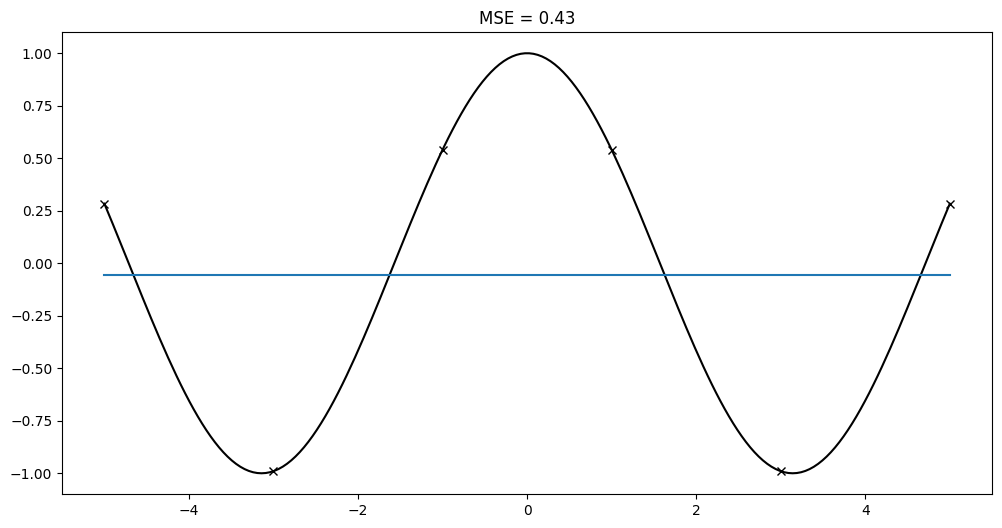

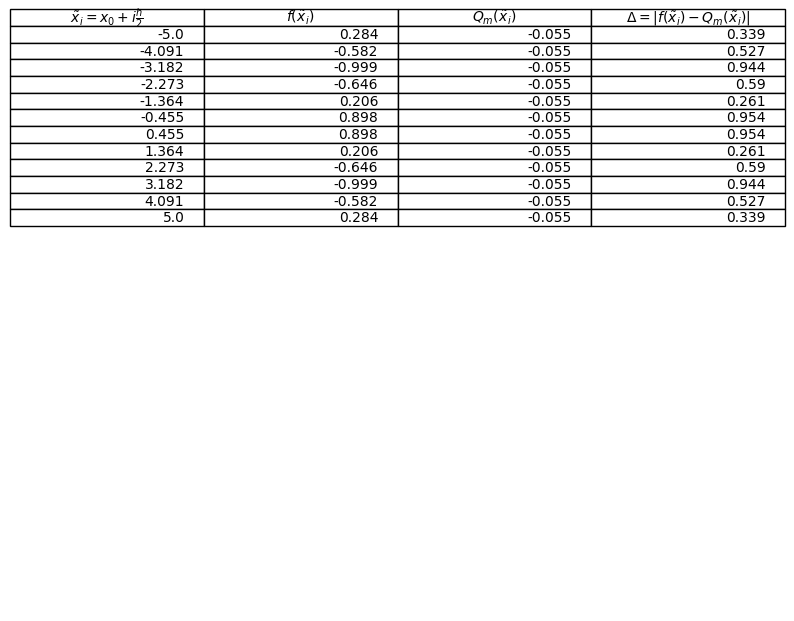

In [21]:
def show_plot(f, a_b, n, m):
    a, b = a_b
    x = np.linspace(a, b, n)
    y = f(x)

    x_t = np.linspace(a, b, n * 2)
    y_t = f(x_t)

    ln = np.linspace(a, b, 200)
    fln = f(ln)
    
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(ln, fln, color="black")
    ax.plot(x, y, 'x', color="black")
    

    w = lsm(x, y, m)
    y_hat = np.polyval(np.flip(w), x_t)

    ax.plot(x_t, y_hat)
    ax.set_title(f"MSE = {mse(y_t, y_hat):.2f}")
    
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.table(
        cellText=np.transpose([
            x_t, y_t, y_hat, abs(y_t - y_hat)
        ]).round(3), 
        colLabels=[
            r'$\tilde x_i = x_0 + i\frac{h}{2}$',
            r'$f(\tilde x_i)$',
            r'$Q_m(\tilde x_i)$',
            r'$\Delta = |f(\tilde x_i) - Q_m(\tilde x_i)|$',
        ],
        loc="top"
    )    
    ax2.axis("off")

f = np.cos
a_b = -5, 5
n = 6
m = 1
show_plot(f, a_b, n, m)
